<a href="https://colab.research.google.com/github/Sravanalakshmi09/Internship/blob/main/Internship/Day%2010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression for SignalSense — IoT Sensor Anomaly Detection Dashboard

This section will demonstrate how to build a logistic regression model to classify spam messages using the 'synthetic_iot_dataset.csv' dataset.

First 5 Rows
  Device_ID  Temperature   Humidity  Battery_Level  Anomaly
0  Device_1    32.483571  43.248217             43        0
1  Device_2    29.308678  48.554813             70        0
2  Device_3    33.238443  42.075801             29        0
3  Device_4    37.615149  46.920385             91        0
4  Device_5    28.829233  31.063853             40        0

Dataset Shape: (2000, 5)

Missing Values
Device_ID        0
Temperature      0
Humidity         0
Battery_Level    0
Anomaly          0
dtype: int64

Features:
Index(['Temperature', 'Humidity', 'Battery_Level'], dtype='object')

Best Hyperparameters
{'C': np.float64(3.7554011884736247), 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross Validation Accuracy
1.0

Test Accuracy
99.75%

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       361
           1       1.00      0.97      0.99        39

    accuracy                           1.00       400
   

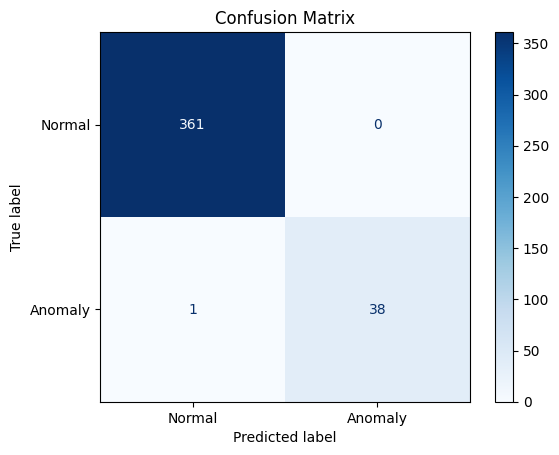


Feature Importance
         Feature  Coefficient  Absolute
0    Temperature     4.550294  4.550294
2  Battery_Level    -2.576388  2.576388
1       Humidity     0.056904  0.056904


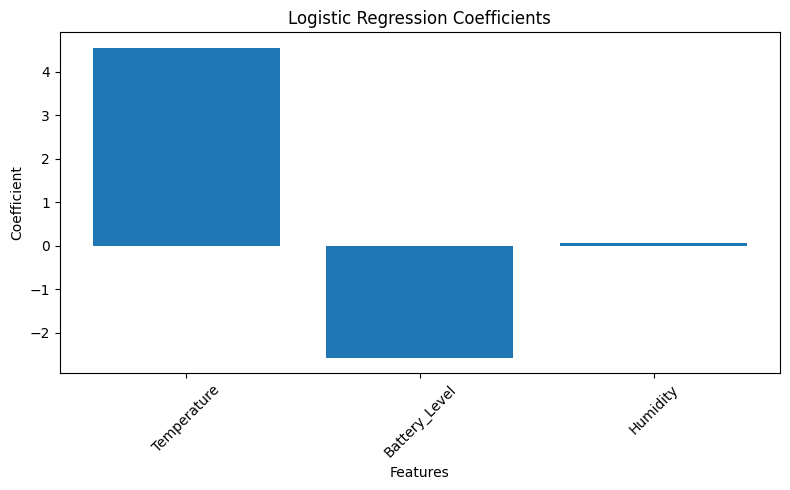


New Sensor Prediction
Probability (Normal): 0.9999
Probability (Anomaly): 0.0001
✅ Normal Sensor

Model Saved Successfully!
signalsense_logistic_randomsearch_model.pkl
signalsense_scaler.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================================
# SignalSense - IoT Sensor Anomaly Detection
# Logistic Regression with RandomizedSearchCV
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from scipy.stats import uniform
import joblib

# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("/content/drive/MyDrive/synthetic_iot_dataset.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

# ============================================================
# Prepare Features and Target
# ============================================================

X = df.drop(columns=["Device_ID", "Anomaly"])
y = df["Anomaly"]

print("\nFeatures:")
print(X.columns)

# ============================================================
# Split Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# Logistic Regression Model
# ============================================================

log_model = LogisticRegression(max_iter=1000)

# ============================================================
# Hyperparameter Search Space
# ============================================================

param_dist = {
    "C": uniform(0.01, 10),
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear", "newton-cg", "saga"]
}

# ============================================================
# Randomized Search CV
# ============================================================

random_search = RandomizedSearchCV(
    estimator=log_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# ============================================================
# Best Parameters
# ============================================================

print("\n===================================")
print("Best Hyperparameters")
print("===================================")

print(random_search.best_params_)

print("\nBest Cross Validation Accuracy")
print(random_search.best_score_)

# ============================================================
# Best Model
# ============================================================

best_model = random_search.best_estimator_

# ============================================================
# Predictions
# ============================================================

y_pred = best_model.predict(X_test)

# ============================================================
# Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("Test Accuracy")
print("===================================")

print(f"{accuracy*100:.2f}%")

# ============================================================
# Classification Report
# ============================================================

print("\n===================================")
print("Classification Report")
print("===================================")

print(classification_report(y_test, y_pred))

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ============================================================
# Feature Importance (Coefficients)
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

print("\n===================================")
print("Feature Importance")
print("===================================")

print(importance)

# Plot Feature Importance
plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Coefficient"])
plt.xticks(rotation=45)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()

# ============================================================
# Predict New Sensor Reading
# ============================================================

# Format:
# [Temperature, Humidity, Battery_Level]

new_sensor = [[35.2, 48.0, 65]]

new_sensor_scaled = scaler.transform(new_sensor)

prediction = best_model.predict(new_sensor_scaled)[0]
probability = best_model.predict_proba(new_sensor_scaled)[0]

print("\n===================================")
print("New Sensor Prediction")
print("===================================")

print(f"Probability (Normal): {probability[0]:.4f}")
print(f"Probability (Anomaly): {probability[1]:.4f}")

if prediction == 1:
    print("🚨 Anomaly Detected")
else:
    print("✅ Normal Sensor")

# ============================================================
# Save Model
# ============================================================

joblib.dump(best_model, "signalsense_logistic_randomsearch_model.pkl")
joblib.dump(scaler, "signalsense_scaler.pkl")

print("\nModel Saved Successfully!")
print("signalsense_logistic_randomsearch_model.pkl")
print("signalsense_scaler.pkl")

### Train Logistic Regression Model

Initialize and train a Logistic Regression model on the TF-IDF transformed training data.

In [ ]:
model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
pip install joblib

### Save the Trained Logistic Regression Model

It's good practice to save trained models for future use without retraining. We'll use the `joblib` library for this.

In [ ]:
import joblib
from sklearn.linear_model import LogisticRegression # Ensure LogisticRegression is imported

# Re-initialize and train the Logistic Regression model if 'model' is not defined or to ensure it's up-to-date
# This assumes X_train and y_train are available from prior cell executions.

# Initialize the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model
# Ensure X_train and y_train are defined by executing relevant preceding cells
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully (or re-trained for saving)!")

# Define the filename for the trained model
model_filename = 'logistic_regression_signal_sensor.pkl'

# Save the trained model to disk
joblib.dump(model, model_filename)

print(f"Trained Logistic Regression model saved as '{model_filename}'")

Logistic Regression model trained successfully (or re-trained for saving)!
Trained Logistic Regression model saved as 'logistic_regression_signal_sensor.pkl'


### Load the Saved Logistic Regression Model

Now, let's load the model back from the saved `.pkl` file to ensure it works correctly and then re-evaluate it.

In [ ]:
# Load the saved model
loaded_model = joblib.load(model_filename)

print(f"Logistic Regression model loaded from '{model_filename}'")

# Make predictions using the loaded model
y_pred_loaded = loaded_model.predict(X_test)

# Evaluate the loaded model
accuracy_loaded = accuracy_score(y_test, y_pred_loaded)
report_loaded = classification_report(y_test, y_pred_loaded)

print(f"\nAccuracy of loaded model: {accuracy_loaded:.4f}")
print("\nClassification Report of loaded model:")
print(report_loaded)

# Define y_pred for comparison (if 'model' is available from a previous cell)
# This assumes the 'model' variable is still in the kernel from prior training (e.g., cell 7facc5af).
# If not, you might need to re-run the model training cell explicitly before this one.
try:
    y_pred = model.predict(X_test)
except NameError:
    print("Warning: 'model' variable not found. Skipping direct comparison with original model predictions.")
    y_pred = None # Set to None or handle as appropriate if original model predictions are critical

# Verify that predictions are identical
if y_pred is not None and (y_pred == y_pred_loaded).all():
    print("\nVerification successful: Predictions from original and loaded models are identical.")
elif y_pred is not None:
    print("\nVerification failed: Predictions from original and loaded models differ.")
else:
    print("\nVerification could not be performed due to missing original model predictions (y_pred).")

Logistic Regression model loaded from 'logistic_regression_signal_sensor.pkl'

Accuracy of loaded model: 0.9975

Classification Report of loaded model:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       361
           1       1.00      0.97      0.99        39

    accuracy                           1.00       400
   macro avg       1.00      0.99      0.99       400
weighted avg       1.00      1.00      1.00       400


Verification successful: Predictions from original and loaded models are identical.
